# 2. Model: MDP, politika i učenje

Šta se ovde pokazuje: kako se projektovanje mreže pretvara u niz odluka, kako
izgleda mreža koja te odluke donosi, i zašto se uči REINFORCE-om a ne
klasičnim supervizovanim učenjem.

Ovo je deo koji se ne vidi iz tabela.

In [1]:
import sys
from pathlib import Path

KOREN = Path.cwd().parent
sys.path.insert(0, str(KOREN))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 2.1 MDP

Epizoda gradi svih R linija redom. Za svaku liniju prvo se bira početni čvor,
pa se naizmenično bira proširenje ili kraj. Akcija je par (kraj, čvor).

*(popuniti: zašto par a ne samo čvor)*

In [2]:
from tndp.rl.env import TndpEnv, EXTEND, HALT, HEAD, TAIL
from tndp.synth import generate_city

grad = generate_city(seed=0, n_range=(12, 16))
env = TndpEnv(grad, num_routes=3, min_len=2, max_len=8, alpha=0.5)

odluka, maska = env.decision()
print("tip odluke:", "EXTEND" if odluka == EXTEND else "HALT")
print("oblik maske:", maska.shape, "  dozvoljenih poteza:", maska.sum())
print("dozvoljeni pocetni cvorovi:", np.flatnonzero(maska[HEAD]))

tip odluke: EXTEND
oblik maske: (2, 16)   dozvoljenih poteza: 16
dozvoljeni pocetni cvorovi: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


## 2.2 Jedna epizoda, potez po potez

*(popuniti: šta se vidi iz ispisa)*

In [3]:
import torch
from tndp.rl.model import TndpPolicy
from tndp.rl.features import node_features, edge_tensors

torch.manual_seed(0)
policy = TndpPolicy()
ei, ea = edge_tensors(grad)
env.reset()

korak = 0
while not env.done and korak < 25:
    odluka, maska = env.decision()
    h = policy.encode(node_features(env, policy.features), ei, ea)
    logiti = policy.action_logits(h, odluka, maska, env.ends)
    p = torch.distributions.Categorical(logits=logiti)
    a = int(torch.multinomial(p.probs, 1))
    kraj = (odluka == HALT and a == len(logiti) - 1)
    print(f"{korak:2d}  linija {len(env.routes)}  tekuca {env.current}  "
          f"{'KRAJ LINIJE' if kraj else f'dodaj cvor {a % grad.n}'}")
    env.step(-1 if kraj else a)
    korak += 1

print("\nmreza:", env.routes)

 0  linija 0  tekuca []  dodaj cvor 3
 1  linija 0  tekuca [3]  dodaj cvor 14
 2  linija 0  tekuca [3, 14]  dodaj cvor 4
 3  linija 0  tekuca [3, 14, 4]  KRAJ LINIJE
 4  linija 1  tekuca []  dodaj cvor 14
 5  linija 1  tekuca [14]  dodaj cvor 3
 6  linija 1  tekuca [14, 3]  dodaj cvor 4
 7  linija 1  tekuca [4, 14, 3]  dodaj cvor 11
 8  linija 1  tekuca [4, 14, 3, 11]  dodaj cvor 8
 9  linija 1  tekuca [4, 14, 3, 11, 8]  dodaj cvor 15
10  linija 1  tekuca [4, 14, 3, 11, 8, 15]  KRAJ LINIJE
11  linija 2  tekuca []  dodaj cvor 10
12  linija 2  tekuca [10]  dodaj cvor 8
13  linija 2  tekuca [10, 8]  dodaj cvor 9
14  linija 2  tekuca [10, 8, 9]  KRAJ LINIJE

mreza: [[3, 14, 4], [4, 14, 3, 11, 8, 15], [10, 8, 9]]


## 2.3 Arhitektura

GATv2 enkoder, pa tri glave: pointer za izbor čvora, halt, i value kao baseline.

*(popuniti: zašto GNN a ne MLP, šta znači da je broj parametara nezavisan od n)*

In [4]:
print(policy)
print("\nparametara:", sum(p.numel() for p in policy.parameters()))
x = node_features(env, policy.features)
print("node featura:", x.shape, " edge featura:", ea.shape)

TndpPolicy(
  (embed): Linear(in_features=13, out_features=64, bias=True)
  (convs): ModuleList(
    (0-2): 3 x GATv2Conv(64, 16, heads=4)
  )
  (node_score): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (halt_score): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (value): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

parametara: 47491
node featura: torch.Size([16, 13])  edge featura: torch.Size([42, 2])


## 2.4 Nagrada

Nagrada postoji tek kad je cela mreža gotova. Oba člana su odnos prema svojoj
donjoj granici, pa `alpha` stvarno balansira.

*(popuniti: zašto se nepokriven par naplaćuje kroz C_p_all a ne zasebnom kaznom)*

In [5]:
from tndp.core.assignment import cost_scales, objective, UNSERVED_FACTOR

nagrada, res = env.reward()
cp_scale, co_scale = cost_scales(grad)
print(f"C_p_all {res.C_p_all:.2f} / {cp_scale:.2f} = {res.C_p_all/cp_scale:.3f}   putnicki clan")
print(f"C_o     {res.C_o:.2f} / {co_scale:.2f} = {res.C_o/co_scale:.3f}   operaterski clan")
print(f"cilj {objective(res, (cp_scale, co_scale), 0.5):.3f}   nagrada {nagrada:.3f}")
print(f"d_un {res.d['d_un']:.3f}   UNSERVED_FACTOR {UNSERVED_FACTOR}")

C_p_all 26.60 / 4.39 = 6.064   putnicki clan
C_o     35.63 / 49.12 = 0.725   operaterski clan
cilj 3.395   nagrada -3.395
d_un 0.642   UNSERVED_FACTOR 8.0


## 2.5 Zašto REINFORCE

Nema tačnog odgovora sa kojim bi se izlaz poredio. Umesto toga se uzorkuje
epizoda, dobija skalar na kraju, i pojačavaju potezi koji su ispali bolji od
proseka.

*(popuniti: gde je razlika u odnosu na supervizovano učenje)*

In [6]:
from tndp.rl.evaluate import rollout

env.reset()
_, nagrada, res, logp, ent = rollout(policy, env, sample=True,
                                     gen=torch.Generator().manual_seed(0))
baseline = policy.state_value(policy.encode(node_features(env.reset(), policy.features), ei, ea))
adv = nagrada - baseline.item()
loss = -(adv * logp) - 0.01 * ent
print(f"nagrada {nagrada:.3f}   baseline {baseline.item():.3f}   advantage {adv:+.3f}")
print(f"suma log verovatnoca {logp.item():.2f}   entropija {ent.item():.2f}")
print(f"loss {loss.item():.3f}")
loss.backward()
print("gradijenti konacni:", all(torch.isfinite(p.grad).all() for p in policy.parameters() if p.grad is not None))

nagrada -3.978   baseline -0.102   advantage -3.876
suma log verovatnoca -15.60   entropija 1.47
loss -60.485


gradijenti konacni: True


## 2.6 Kratak trening

Pravi modeli su u `runs/`; ovde se pušta kratak run samo da se vidi da kriva raste.

*(popuniti: koliko je trajao pravi trening, zašto 12000 iteracija)*

In [7]:
# pravi trening ide iz komandne linije, ne odavde:
#   python -m tndp.rl.train --config configs/gravity-v2.yaml
import sys, subprocess
subprocess.run([sys.executable, "-m", "tndp.rl.train",
                "--config", "configs/smoke.yaml"], cwd=KOREN, check=True)


CompletedProcess(args=['D:\\faks\\Seminarski rad D\\.venv\\Scripts\\python.exe', '-m', 'tndp.rl.train', '--config', 'configs/smoke.yaml'], returncode=0)

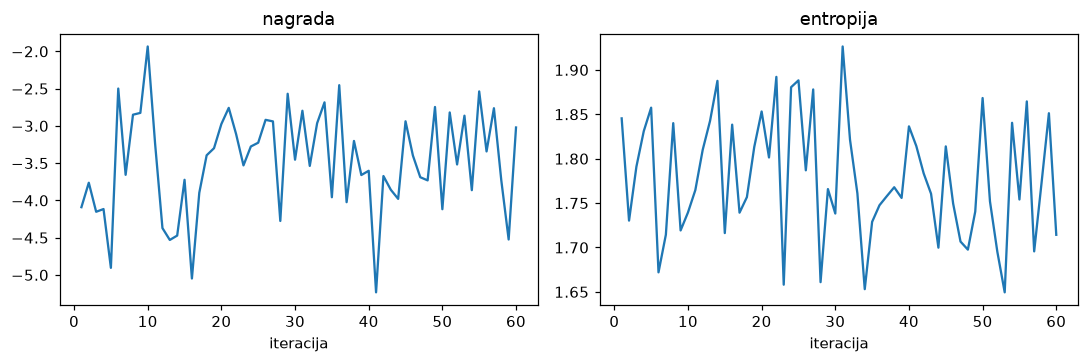

In [8]:
import csv
red = list(csv.DictReader(open(KOREN / "runs" / "smoke" / "log.csv")))
it = [int(r["iter"]) for r in red]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(it, [float(r["reward"]) for r in red]); ax[0].set_title("nagrada")
ax[1].plot(it, [float(r["entropy"]) for r in red]); ax[1].set_title("entropija")
for a in ax: a.set_xlabel("iteracija")
plt.tight_layout()

## Zaključci

*(popuniti)*